# ACCRUE

A PyTorch reproduction of the ACCRUE method proposed by Camporeale and Carè (2021).

ACCRUE transforms deterministic point predictions into Gaussian probabilistic predictions by learning an input-dependent standard deviation.

The implementation has two stages:

1. Train a deterministic model to estimate the predictive mean.
2. Train a separate uncertainty model using the ACCRUE objective

## Reproducibility

In [1]:
import copy
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.metrics import mean_squared_error
from scipy.stats import norm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.11.0
Device: mps


## 1. Experimental configuration

The initial experiment reproduces the one-dimensional G dataset from the ACCRUE paper.

The paper uses:

- 100 observations;
- input domain \(x\in[0,1]\);
- 33% training data;
- 33% validation data;
- 34% test data;
- five independently initialised uncertainty networks.

In [2]:
# Dataset configuration
N_SAMPLES = 100
X_MIN = 0.0
X_MAX = 1.0

# Paper split: 33% training, 33% validation, 34% test
N_TRAIN = 33
N_VALIDATION = 33
N_TEST = 34

# ACCRUE uncertainty-network architecture
HIDDEN_SIZE_1 = 50
HIDDEN_SIZE_2 = 10
N_CANDIDATE_MODELS = 5

# Training configuration
UNCERTAINTY_EPOCHS = 3000
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 300

# Numerical stability
MIN_SIGMA = 1e-4
MAX_SIGMA = 10.0

print("ACCRUE experiment configuration")
print(f"Total observations: {N_SAMPLES}")
print(f"Training observations: {N_TRAIN}")
print(f"Validation observations: {N_VALIDATION}")
print(f"Test observations: {N_TEST}")
print(f"Candidate uncertainty models: {N_CANDIDATE_MODELS}")
print(f"Maximum training epochs: {UNCERTAINTY_EPOCHS}")

ACCRUE experiment configuration
Total observations: 100
Training observations: 33
Validation observations: 33
Test observations: 34
Candidate uncertainty models: 5
Maximum training epochs: 3000


## 2. ACCRUE G synthetic dataset

The G dataset is generated from

\[
y=f(x)+\epsilon,
\]

where

\[
f(x)=2\sin(2\pi x)
\]

and

\[
\epsilon\sim\mathcal{N}(0,\sigma(x)^2),
\qquad
\sigma(x)=0.5x+0.5.
\]

This is a heteroskedastic regression problem because the observation noise increases with \(x\).

In [3]:
def true_mean_function(x):
    """True mean function for the ACCRUE G dataset."""
    return 2.0 * np.sin(2.0 * np.pi * x)


def true_sigma_function(x):
    """True input-dependent standard deviation."""
    return 0.5 * x + 0.5


data_rng = np.random.default_rng(SEED)

# Randomly sample inputs from [0, 1]
x_all = data_rng.uniform(
    X_MIN,
    X_MAX,
    size=(N_SAMPLES, 1),
)

# Calculate the true mean and standard deviation
true_mean_all = true_mean_function(x_all)
true_sigma_all = true_sigma_function(x_all)

# Generate noisy observations
y_all = true_mean_all + data_rng.normal(
    loc=0.0,
    scale=true_sigma_all,
    size=true_mean_all.shape,
)

# Random train-validation-test split
indices = data_rng.permutation(N_SAMPLES)

train_indices = indices[:N_TRAIN]
validation_indices = indices[N_TRAIN:N_TRAIN + N_VALIDATION]
test_indices = indices[N_TRAIN + N_VALIDATION:]

x_train = x_all[train_indices]
y_train = y_all[train_indices]

x_validation = x_all[validation_indices]
y_validation = y_all[validation_indices]

x_test = x_all[test_indices]
y_test = y_all[test_indices]

true_mean_test = true_mean_all[test_indices]
true_sigma_test = true_sigma_all[test_indices]

assert len(x_train) == N_TRAIN
assert len(x_validation) == N_VALIDATION
assert len(x_test) == N_TEST

print("G dataset created successfully")
print(f"x_train shape: {x_train.shape}")
print(f"x_validation shape: {x_validation.shape}")
print(f"x_test shape: {x_test.shape}")
print(
    f"True sigma range: "
    f"[{true_sigma_all.min():.4f}, {true_sigma_all.max():.4f}]"
)

G dataset created successfully
x_train shape: (33, 1)
x_validation shape: (33, 1)
x_test shape: (34, 1)
True sigma range: [0.5037, 0.9878]


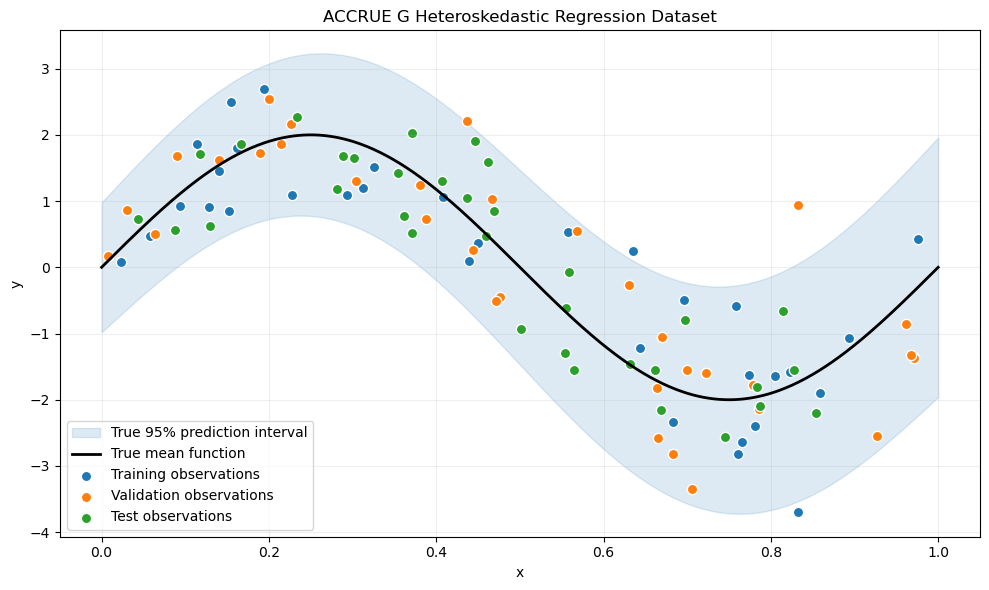

In [4]:
x_plot = np.linspace(
    X_MIN,
    X_MAX,
    500,
).reshape(-1, 1)

mean_plot = true_mean_function(x_plot)
sigma_plot = true_sigma_function(x_plot)

lower_plot = mean_plot - 1.96 * sigma_plot
upper_plot = mean_plot + 1.96 * sigma_plot

plt.figure(figsize=(10, 6))

plt.fill_between(
    x_plot[:, 0],
    lower_plot[:, 0],
    upper_plot[:, 0],
    color="tab:blue",
    alpha=0.15,
    label="True 95% prediction interval",
)

plt.plot(
    x_plot,
    mean_plot,
    color="black",
    linewidth=2,
    label="True mean function",
)

plt.scatter(
    x_train,
    y_train,
    color="tab:blue",
    edgecolor="white",
    s=55,
    label="Training observations",
)

plt.scatter(
    x_validation,
    y_validation,
    color="tab:orange",
    edgecolor="white",
    s=55,
    label="Validation observations",
)

plt.scatter(
    x_test,
    y_test,
    color="tab:green",
    edgecolor="white",
    s=55,
    label="Test observations",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("ACCRUE G Heteroskedastic Regression Dataset")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 3. Deterministic mean model

ACCRUE assumes that a deterministic model already provides the predictive mean.

Following the paper's synthetic experiments, a homoskedastic Gaussian-process regressor is used as the deterministic mean model. The predictive standard deviation produced by the Gaussian process is not used by ACCRUE.

Only the Gaussian-process mean predictions are retained.

In [6]:
gp_kernel = (
    ConstantKernel(
        constant_value=1.0,
        constant_value_bounds=(1e-3, 1e3),
    )
    * RBF(
        length_scale=0.2,
        length_scale_bounds=(1e-3, 1e2),
    )
    + WhiteKernel(
        noise_level=0.5,
        noise_level_bounds=(1e-5, 1e1),
    )
)

mean_model = GaussianProcessRegressor(
    kernel=gp_kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=SEED,
)

mean_model.fit(
    x_train,
    y_train.ravel(),
)

mean_train = mean_model.predict(x_train).reshape(-1, 1)
mean_validation = mean_model.predict(x_validation).reshape(-1, 1)
mean_test = mean_model.predict(x_test).reshape(-1, 1)
mean_plot_gp = mean_model.predict(x_plot).reshape(-1, 1)

residual_train = y_train - mean_train
residual_validation = y_validation - mean_validation
residual_test = y_test - mean_test

train_rmse = np.sqrt(
    mean_squared_error(y_train, mean_train)
)
validation_rmse = np.sqrt(
    mean_squared_error(y_validation, mean_validation)
)
test_rmse = np.sqrt(
    mean_squared_error(y_test, mean_test)
)

In [7]:
print("Gaussian-process mean model trained")
print(f"Optimised kernel: {mean_model.kernel_}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Validation RMSE: {validation_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Gaussian-process mean model trained
Optimised kernel: 0.77**2 * RBF(length_scale=0.146) + WhiteKernel(noise_level=0.201)
Training RMSE: 0.6591
Validation RMSE: 0.9674
Test RMSE: 0.7695


Deterministic mean model visualization

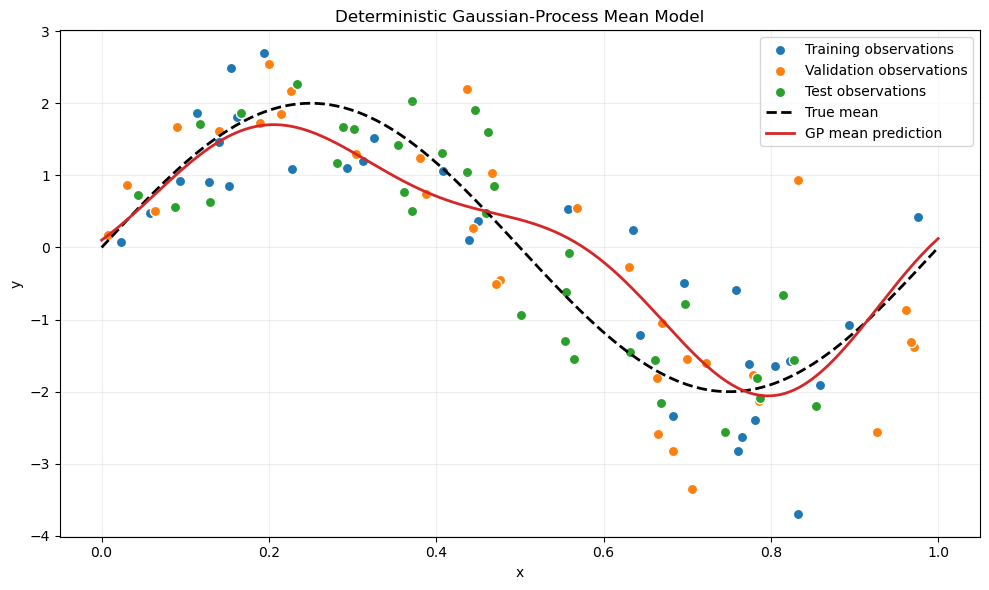

In [8]:
plt.figure(figsize=(10, 6))

plt.scatter(
    x_train,
    y_train,
    color="tab:blue",
    edgecolor="white",
    s=55,
    label="Training observations",
)

plt.scatter(
    x_validation,
    y_validation,
    color="tab:orange",
    edgecolor="white",
    s=55,
    label="Validation observations",
)

plt.scatter(
    x_test,
    y_test,
    color="tab:green",
    edgecolor="white",
    s=55,
    label="Test observations",
)

plt.plot(
    x_plot,
    mean_plot,
    color="black",
    linewidth=2,
    linestyle="--",
    label="True mean",
)

plt.plot(
    x_plot,
    mean_plot_gp,
    color="tab:red",
    linewidth=2,
    label="GP mean prediction",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Deterministic Gaussian-Process Mean Model")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 4. ACCRUE scoring functions

For a Gaussian prediction with error

\[
\epsilon_i = y_i-\mu_i
\]

and predicted standard deviation \(\sigma_i\), ACCRUE combines two quantities.

### Continuous ranked probability score

\[
\mathrm{CRPS}(\epsilon_i,\sigma_i)
=
\sigma_i
\left[
\frac{\epsilon_i}{\sigma_i}
\operatorname{erf}
\left(
\frac{\epsilon_i}{\sqrt{2}\sigma_i}
\right)
+
\sqrt{\frac{2}{\pi}}
\exp
\left(
-\frac{\epsilon_i^2}{2\sigma_i^2}
\right)
-
\frac{1}{\sqrt{\pi}}
\right].
\]

### Reliability score

The standardised errors are

\[
\eta_i =
\frac{\epsilon_i}{\sqrt{2}\sigma_i}.
\]

After sorting these values, the analytic reliability score compares their empirical distribution with the expected Gaussian distribution.

The combined objective is

\[
\mathrm{ACCRUE}
=
\beta\,\overline{\mathrm{CRPS}}
+
(1-\beta)\,\mathrm{RS}.
\]

The reliability term acts as a calibration regulariser for the CRPS term.

#### CRPS and reliability score

In [9]:
def gaussian_crps(errors, sigma):
    """
    Mean continuous ranked probability score for Gaussian forecasts.

    Parameters
    ----------
    errors : torch.Tensor
        Observation minus predicted mean.
    sigma : torch.Tensor
        Predicted standard deviation.
    """
    sigma = torch.clamp(
        sigma,
        min=MIN_SIGMA,
        max=MAX_SIGMA,
    )

    standardised_error = errors / sigma

    individual_crps = sigma * (
        standardised_error
        * torch.erf(standardised_error / math.sqrt(2.0))
        + math.sqrt(2.0 / math.pi)
        * torch.exp(-0.5 * standardised_error**2)
        - 1.0 / math.sqrt(math.pi)
    )

    return individual_crps.mean()


def reliability_score(errors, sigma, include_constant=False):
    """
    Analytic reliability score from the ACCRUE paper.

    The paper omits the final additive constant during optimisation
    because it does not affect the gradients or the optimum.
    """
    sigma = torch.clamp(
        sigma,
        min=MIN_SIGMA,
        max=MAX_SIGMA,
    )

    eta = errors / (math.sqrt(2.0) * sigma)
    eta_sorted, _ = torch.sort(eta.reshape(-1))

    n = eta_sorted.numel()

    ranks = torch.arange(
        1,
        n + 1,
        device=eta_sorted.device,
        dtype=eta_sorted.dtype,
    )

    terms = (
        eta_sorted / n
        * (torch.erf(eta_sorted) + 1.0)
        - eta_sorted / (n**2)
        * (2.0 * ranks - 1.0)
        + torch.exp(-(eta_sorted**2))
        / (math.sqrt(math.pi) * n)
    )

    score = terms.sum()

    if include_constant:
        score = score - 0.5 * math.sqrt(2.0 / math.pi)

    return score

ACCRUE weighting factor

In [10]:
def calculate_beta(errors):
    """
    Calculate the heuristic scaling factor from the ACCRUE paper.
    """
    errors = errors.reshape(-1)
    n = errors.numel()

    crps_min = (
        math.sqrt(math.log(4.0))
        / 2.0
        * torch.mean(torch.abs(errors))
    )

    ranks = torch.arange(
        1,
        n + 1,
        device=errors.device,
        dtype=errors.dtype,
    )

    erf_arguments = (
        (2.0 * ranks - 1.0) / n
        - 1.0
    )

    eta_at_rs_min = torch.erfinv(erf_arguments)

    # Shifted minimum used in the practical implementation.
    rs_min = torch.mean(
        torch.exp(-(eta_at_rs_min**2))
    ) / math.sqrt(math.pi)

    beta = rs_min / (crps_min + rs_min)

    return beta.detach()


train_residual_tensor_for_beta = torch.tensor(
    residual_train,
    dtype=torch.float32,
    device=device,
)

BETA = calculate_beta(
    train_residual_tensor_for_beta
)

print(f"ACCRUE beta: {BETA.item():.6f}")
print(f"CRPS weight: {BETA.item():.6f}")
print(f"Reliability weight: {1.0 - BETA.item():.6f}")

ACCRUE beta: 0.557886
CRPS weight: 0.557886
Reliability weight: 0.442114


In [12]:
# Combined Objective

def accrue_loss(errors, sigma, beta):
    crps = gaussian_crps(
        errors,
        sigma,
    )

    rs = reliability_score(
        errors,
        sigma,
        include_constant=False,
    )

    total = (
        beta * crps
        + (1.0 - beta) * rs
    )

    return total, crps, rs

## 5. Input-dependent uncertainty network

The uncertainty network receives \(x\) and predicts \(\log \sigma(x)\).

The architecture follows the paper:

- one input variable;
- first hidden layer with 50 neurons and ReLU activation;
- second hidden layer with 10 neurons and a symmetric saturating activation;
- one output representing \(\log \sigma\).

Exponentiating the output ensures that the predicted standard deviation remains positive.

In [14]:
# uncertain network

class AccrueUncertaintyNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.hidden_1 = nn.Linear(
            1,
            HIDDEN_SIZE_1,
        )

        self.hidden_2 = nn.Linear(
            HIDDEN_SIZE_1,
            HIDDEN_SIZE_2,
        )

        self.output_layer = nn.Linear(
            HIDDEN_SIZE_2,
            1,
        )

    def forward(self, x):
        hidden = F.relu(
            self.hidden_1(x)
        )

        # Symmetric saturating linear activation
        hidden = F.hardtanh(
            self.hidden_2(hidden),
            min_val=-1.0,
            max_val=1.0,
        )

        log_sigma = self.output_layer(hidden)

        log_sigma = torch.clamp(
            log_sigma,
            min=math.log(MIN_SIGMA),
            max=math.log(MAX_SIGMA),
        )

        sigma = torch.exp(log_sigma)

        return sigma

#### Converting the data to PyTorch tensors

In [15]:
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32,
    device=device,
)

x_validation_tensor = torch.tensor(
    x_validation,
    dtype=torch.float32,
    device=device,
)

x_test_tensor = torch.tensor(
    x_test,
    dtype=torch.float32,
    device=device,
)

x_plot_tensor = torch.tensor(
    x_plot,
    dtype=torch.float32,
    device=device,
)

residual_train_tensor = torch.tensor(
    residual_train,
    dtype=torch.float32,
    device=device,
)

residual_validation_tensor = torch.tensor(
    residual_validation,
    dtype=torch.float32,
    device=device,
)

residual_test_tensor = torch.tensor(
    residual_test,
    dtype=torch.float32,
    device=device,
)

print("PyTorch tensors created")
print(f"x_train_tensor: {x_train_tensor.shape}")
print(f"residual_train_tensor: {residual_train_tensor.shape}")

PyTorch tensors created
x_train_tensor: torch.Size([33, 1])
residual_train_tensor: torch.Size([33, 1])


#### Training function

In [16]:
def train_uncertainty_model(model_seed):
    random.seed(model_seed)
    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    model = AccrueUncertaintyNetwork().to(device)

    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    best_state = None

    history = {
        "train_loss": [],
        "validation_loss": [],
        "train_crps": [],
        "validation_crps": [],
        "train_rs": [],
        "validation_rs": [],
    }

    for epoch in range(1, UNCERTAINTY_EPOCHS + 1):
        model.train()
        optimiser.zero_grad()

        sigma_train = model(
            x_train_tensor
        )

        train_loss, train_crps, train_rs = accrue_loss(
            residual_train_tensor,
            sigma_train,
            BETA,
        )

        train_loss.backward()
        optimiser.step()

        model.eval()

        with torch.no_grad():
            sigma_validation = model(
                x_validation_tensor
            )

            validation_loss, validation_crps, validation_rs = accrue_loss(
                residual_validation_tensor,
                sigma_validation,
                BETA,
            )

        history["train_loss"].append(
            train_loss.item()
        )
        history["validation_loss"].append(
            validation_loss.item()
        )
        history["train_crps"].append(
            train_crps.item()
        )
        history["validation_crps"].append(
            validation_crps.item()
        )
        history["train_rs"].append(
            train_rs.item()
        )
        history["validation_rs"].append(
            validation_rs.item()
        )

        current_validation_loss = validation_loss.item()

        if current_validation_loss < best_validation_loss - 1e-7:
            best_validation_loss = current_validation_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            best_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    model.load_state_dict(best_state)

    result = {
        "model": model,
        "history": history,
        "best_epoch": best_epoch,
        "best_validation_loss": best_validation_loss,
        "epochs_completed": len(history["train_loss"]),
        "seed": model_seed,
    }

    return result

#### Training five independently initialised models

In [17]:
candidate_results = []

for candidate_index in range(N_CANDIDATE_MODELS):
    candidate_seed = SEED + candidate_index

    result = train_uncertainty_model(
        model_seed=candidate_seed
    )

    candidate_results.append(result)

    print(
        f"Candidate {candidate_index + 1}/{N_CANDIDATE_MODELS} | "
        f"seed={candidate_seed} | "
        f"best epoch={result['best_epoch']} | "
        f"epochs completed={result['epochs_completed']} | "
        f"best validation loss="
        f"{result['best_validation_loss']:.6f}"
    )

Candidate 1/5 | seed=42 | best epoch=68 | epochs completed=368 | best validation loss=0.469481
Candidate 2/5 | seed=43 | best epoch=110 | epochs completed=410 | best validation loss=0.470726
Candidate 3/5 | seed=44 | best epoch=240 | epochs completed=540 | best validation loss=0.470684
Candidate 4/5 | seed=45 | best epoch=252 | epochs completed=552 | best validation loss=0.470418
Candidate 5/5 | seed=46 | best epoch=176 | epochs completed=476 | best validation loss=0.470970


#### Selecting the best uncertainty model

In [18]:
candidate_results = sorted(
    candidate_results,
    key=lambda result: result["best_validation_loss"],
)

best_result = candidate_results[0]
best_model = best_result["model"]
best_history = best_result["history"]

print("Best ACCRUE uncertainty model selected")
print(f"Seed: {best_result['seed']}")
print(f"Best epoch: {best_result['best_epoch']}")
print(
    f"Best validation loss: "
    f"{best_result['best_validation_loss']:.6f}"
)

Best ACCRUE uncertainty model selected
Seed: 42
Best epoch: 68
Best validation loss: 0.469481


Comparing the models

In [19]:
candidate_table = pd.DataFrame(
    {
        "rank": np.arange(
            1,
            len(candidate_results) + 1,
        ),
        "seed": [
            result["seed"]
            for result in candidate_results
        ],
        "best_epoch": [
            result["best_epoch"]
            for result in candidate_results
        ],
        "epochs_completed": [
            result["epochs_completed"]
            for result in candidate_results
        ],
        "best_validation_loss": [
            result["best_validation_loss"]
            for result in candidate_results
        ],
    }
)

candidate_table

,rank,seed,best_epoch,epochs_completed,best_validation_loss
0,1,42,68,368,0.469481
1,2,45,252,552,0.470418
2,3,44,240,540,0.470684
3,4,43,110,410,0.470726
4,5,46,176,476,0.470970


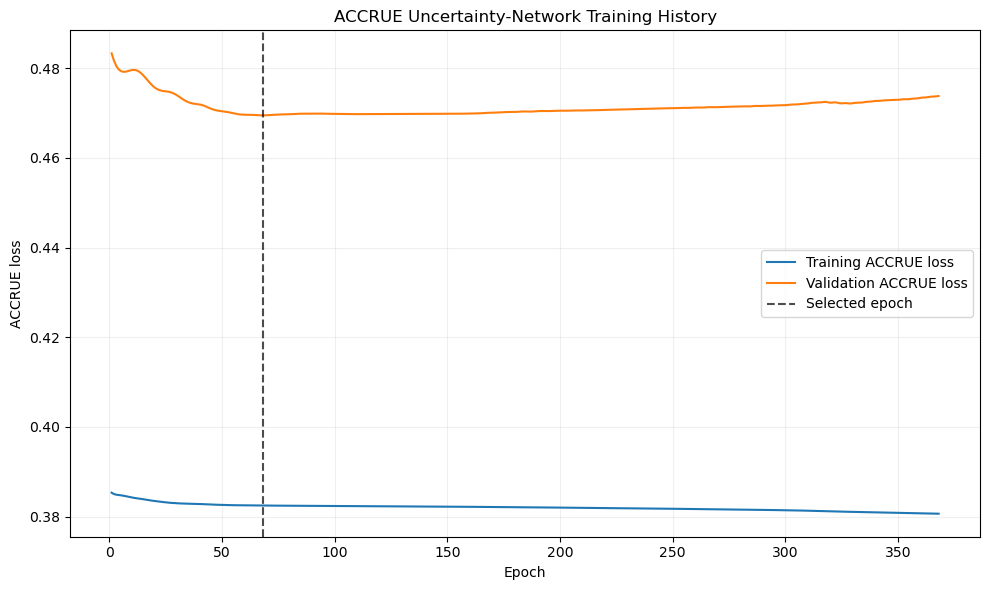

In [20]:
epochs = np.arange(
    1,
    len(best_history["train_loss"]) + 1,
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    best_history["train_loss"],
    label="Training ACCRUE loss",
    color="tab:blue",
)

plt.plot(
    epochs,
    best_history["validation_loss"],
    label="Validation ACCRUE loss",
    color="tab:orange",
)

plt.axvline(
    best_result["best_epoch"],
    color="black",
    linestyle="--",
    alpha=0.7,
    label="Selected epoch",
)

plt.xlabel("Epoch")
plt.ylabel("ACCRUE loss")
plt.title("ACCRUE Uncertainty-Network Training History")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Predictions

In [21]:
best_model.eval()

with torch.no_grad():
    sigma_train_pred = (
        best_model(x_train_tensor)
        .cpu()
        .numpy()
    )

    sigma_validation_pred = (
        best_model(x_validation_tensor)
        .cpu()
        .numpy()
    )

    sigma_test_pred = (
        best_model(x_test_tensor)
        .cpu()
        .numpy()
    )

    sigma_plot_pred = (
        best_model(x_plot_tensor)
        .cpu()
        .numpy()
    )

print("Uncertainty predictions generated")
print(
    f"Test sigma range: "
    f"[{sigma_test_pred.min():.4f}, "
    f"{sigma_test_pred.max():.4f}]"
)

Uncertainty predictions generated
Test sigma range: [0.4682, 0.8844]


#### Learned uncertainty function

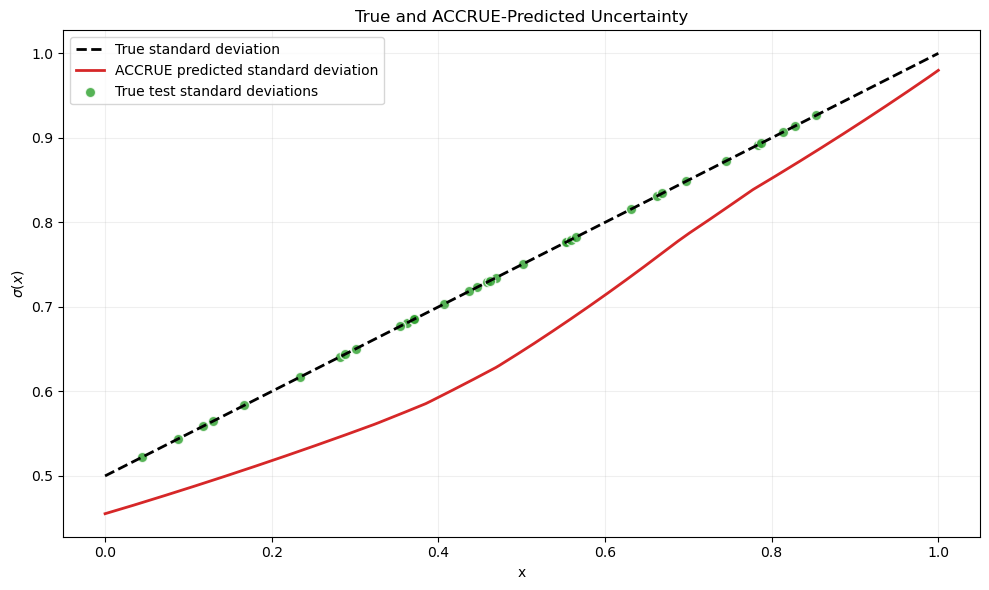

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    x_plot,
    sigma_plot,
    color="black",
    linewidth=2,
    linestyle="--",
    label="True standard deviation",
)

plt.plot(
    x_plot,
    sigma_plot_pred,
    color="tab:red",
    linewidth=2,
    label="ACCRUE predicted standard deviation",
)

plt.scatter(
    x_test,
    true_sigma_test,
    color="tab:green",
    edgecolor="white",
    s=55,
    alpha=0.8,
    label="True test standard deviations",
)

plt.xlabel("x")
plt.ylabel(r"$\sigma(x)$")
plt.title("True and ACCRUE-Predicted Uncertainty")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

#### Probabilistic Prediction

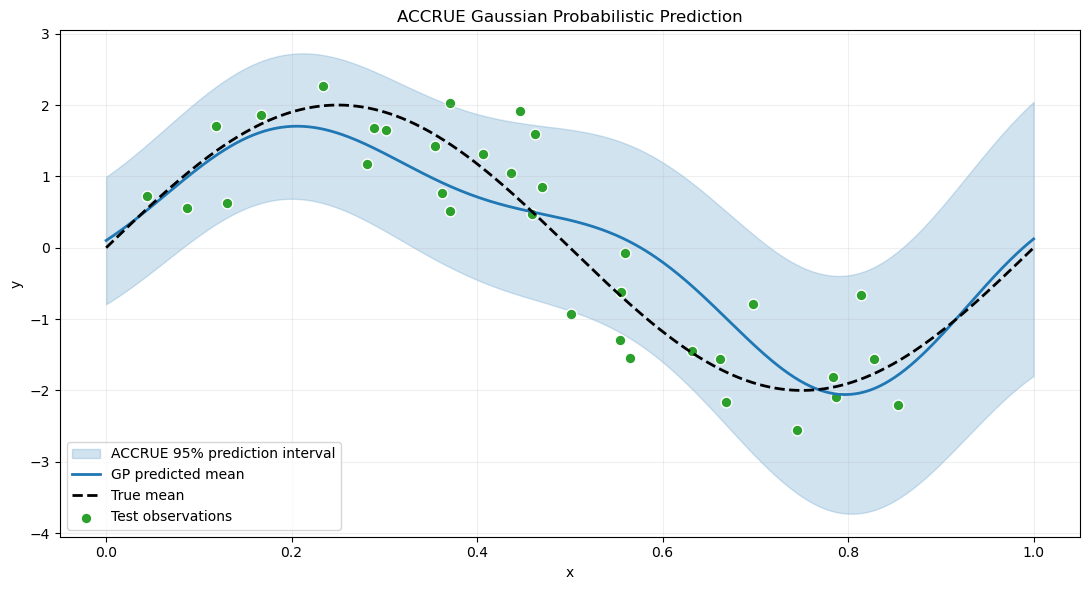

In [23]:
lower_accrue = (
    mean_plot_gp
    - 1.96 * sigma_plot_pred
)

upper_accrue = (
    mean_plot_gp
    + 1.96 * sigma_plot_pred
)

plt.figure(figsize=(11, 6))

plt.fill_between(
    x_plot[:, 0],
    lower_accrue[:, 0],
    upper_accrue[:, 0],
    color="tab:blue",
    alpha=0.2,
    label="ACCRUE 95% prediction interval",
)

plt.plot(
    x_plot,
    mean_plot_gp,
    color="tab:blue",
    linewidth=2,
    label="GP predicted mean",
)

plt.plot(
    x_plot,
    mean_plot,
    color="black",
    linewidth=2,
    linestyle="--",
    label="True mean",
)

plt.scatter(
    x_test,
    y_test,
    color="tab:green",
    edgecolor="white",
    s=60,
    label="Test observations",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("ACCRUE Gaussian Probabilistic Prediction")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Test-set evaluation

The model is evaluated using:

- mean RMSE;
- standard-deviation RMSE;
- Gaussian negative log-likelihood;
- continuous ranked probability score;
- reliability score;
- empirical 68% and 95% interval coverage;
- calibration error calculated from the Gaussian probability integral transform.

For a well-calibrated Gaussian model, approximately 68% and 95% of observations should fall inside the corresponding prediction intervals.

In [24]:
def gaussian_nll_numpy(errors, sigma):
    sigma = np.clip(
        sigma,
        MIN_SIGMA,
        MAX_SIGMA,
    )

    return np.mean(
        np.log(sigma)
        + 0.5 * (errors / sigma) ** 2
        + 0.5 * np.log(2.0 * np.pi)
    )


def interval_coverage(errors, sigma, z_value):
    inside_interval = (
        np.abs(errors)
        <= z_value * sigma
    )

    return np.mean(inside_interval)


def reliability_curve(errors, sigma):
    sigma = np.clip(
        sigma,
        MIN_SIGMA,
        MAX_SIGMA,
    )

    pit_values = norm.cdf(
        errors.reshape(-1)
        / sigma.reshape(-1)
    )

    predicted_probability = np.sort(
        pit_values
    )

    observed_frequency = (
        np.arange(1, len(pit_values) + 1)
        / len(pit_values)
    )

    return predicted_probability, observed_frequency


def calibration_mae(errors, sigma):
    predicted, observed = reliability_curve(
        errors,
        sigma,
    )

    return np.mean(
        np.abs(observed - predicted)
    )

In [25]:
test_errors = residual_test.reshape(-1)
test_sigma = sigma_test_pred.reshape(-1)

with torch.no_grad():
    test_crps = gaussian_crps(
        residual_test_tensor,
        torch.tensor(
            sigma_test_pred,
            dtype=torch.float32,
            device=device,
        ),
    ).item()

    test_rs = reliability_score(
        residual_test_tensor,
        torch.tensor(
            sigma_test_pred,
            dtype=torch.float32,
            device=device,
        ),
        include_constant=True,
    ).item()

test_nll = gaussian_nll_numpy(
    test_errors,
    test_sigma,
)

sigma_rmse = np.sqrt(
    mean_squared_error(
        true_sigma_test.reshape(-1),
        test_sigma,
    )
)

coverage_68 = interval_coverage(
    test_errors,
    test_sigma,
    z_value=1.0,
)

coverage_95 = interval_coverage(
    test_errors,
    test_sigma,
    z_value=1.96,
)

test_calibration_mae = calibration_mae(
    test_errors,
    test_sigma,
)

metrics = pd.DataFrame(
    {
        "Metric": [
            "Mean RMSE",
            "Sigma RMSE",
            "Gaussian NLL",
            "CRPS",
            "Reliability score",
            "Calibration MAE",
            "68% coverage",
            "95% coverage",
        ],
        "Value": [
            test_rmse,
            sigma_rmse,
            test_nll,
            test_crps,
            test_rs,
            test_calibration_mae,
            coverage_68,
            coverage_95,
        ],
    }
)

metrics

,Metric,Value
0,Mean RMSE,0.769487
1,Sigma RMSE,0.085718
2,Gaussian NLL,1.155936
3,CRPS,0.440039
4,Reliability score,0.007957
5,Calibration MAE,0.044183
6,68% coverage,0.617647
7,95% coverage,0.852941


#### Reliability diagram

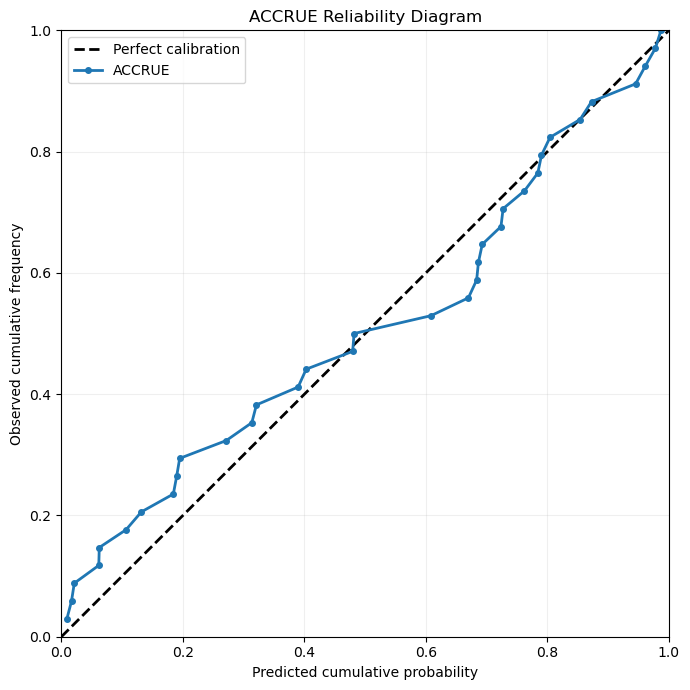

In [26]:
predicted_probability, observed_frequency = reliability_curve(
    test_errors,
    test_sigma,
)

plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Perfect calibration",
)

plt.plot(
    predicted_probability,
    observed_frequency,
    color="tab:blue",
    linewidth=2,
    marker="o",
    markersize=4,
    label="ACCRUE",
)

plt.xlabel("Predicted cumulative probability")
plt.ylabel("Observed cumulative frequency")
plt.title("ACCRUE Reliability Diagram")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

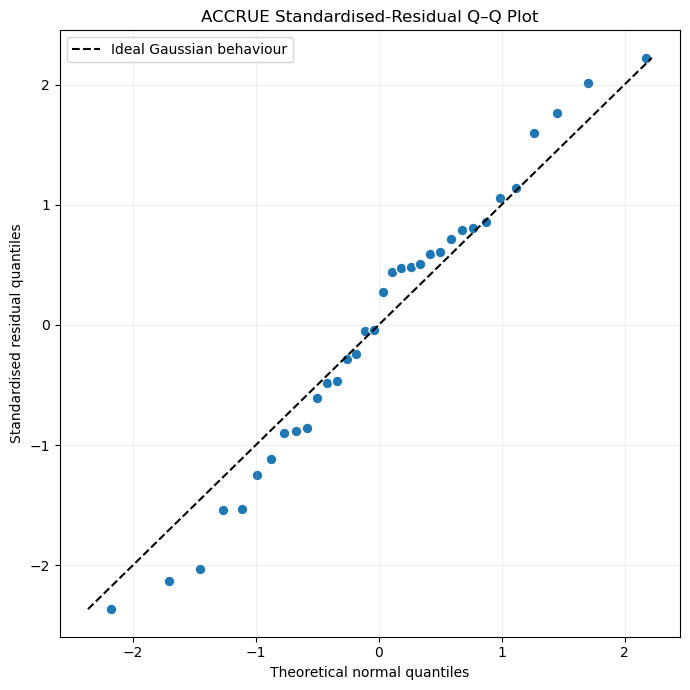

In [27]:
standardised_residuals = (
    test_errors / test_sigma
)

normal_quantiles = norm.ppf(
    (
        np.arange(1, len(standardised_residuals) + 1)
        - 0.5
    )
    / len(standardised_residuals)
)

sorted_standardised_residuals = np.sort(
    standardised_residuals
)

plt.figure(figsize=(7, 7))

plt.scatter(
    normal_quantiles,
    sorted_standardised_residuals,
    color="tab:blue",
    edgecolor="white",
    s=60,
)

plot_min = min(
    normal_quantiles.min(),
    sorted_standardised_residuals.min(),
)

plot_max = max(
    normal_quantiles.max(),
    sorted_standardised_residuals.max(),
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    color="black",
    linestyle="--",
    label="Ideal Gaussian behaviour",
)

plt.xlabel("Theoretical normal quantiles")
plt.ylabel("Standardised residual quantiles")
plt.title("ACCRUE Standardised-Residual Q–Q Plot")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [28]:
import json
from pathlib import Path

results_directory = Path(
    "results/accrue_g"
)

results_directory.mkdir(
    parents=True,
    exist_ok=True,
)

test_results = pd.DataFrame(
    {
        "x": x_test.reshape(-1),
        "observation": y_test.reshape(-1),
        "predicted_mean": mean_test.reshape(-1),
        "predicted_sigma": sigma_test_pred.reshape(-1),
        "true_mean": true_mean_test.reshape(-1),
        "true_sigma": true_sigma_test.reshape(-1),
        "residual": residual_test.reshape(-1),
    }
).sort_values("x")

test_results.to_csv(
    results_directory / "test_predictions.csv",
    index=False,
)

candidate_table.to_csv(
    results_directory / "candidate_models.csv",
    index=False,
)

metrics.to_csv(
    results_directory / "metrics.csv",
    index=False,
)

summary = {
    "dataset": "ACCRUE G",
    "seed": SEED,
    "device": str(device),
    "total_observations": N_SAMPLES,
    "training_observations": N_TRAIN,
    "validation_observations": N_VALIDATION,
    "test_observations": N_TEST,
    "candidate_models": N_CANDIDATE_MODELS,
    "selected_model_seed": int(best_result["seed"]),
    "selected_epoch": int(best_result["best_epoch"]),
    "beta": float(BETA.item()),
    "mean_rmse": float(test_rmse),
    "sigma_rmse": float(sigma_rmse),
    "gaussian_nll": float(test_nll),
    "crps": float(test_crps),
    "reliability_score": float(test_rs),
    "calibration_mae": float(test_calibration_mae),
    "coverage_68": float(coverage_68),
    "coverage_95": float(coverage_95),
}

with open(
    results_directory / "summary.json",
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        summary,
        summary_file,
        indent=2,
    )

cpu_state_dict = {
    name: parameter.detach().cpu()
    for name, parameter in best_model.state_dict().items()
}

torch.save(
    cpu_state_dict,
    results_directory / "uncertainty_model.pt",
)

print(f"Results saved to: {results_directory}")
print("Saved files:")

for saved_file in sorted(results_directory.iterdir()):
    print(f"  - {saved_file.name}")

Results saved to: results/accrue_g
Saved files:
  - candidate_models.csv
  - metrics.csv
  - summary.json
  - test_predictions.csv
  - uncertainty_model.pt


## 7. Conclusion

This notebook implemented ACCRUE as a two-stage uncertainty-quantification method.

1. A deterministic Gaussian-process model estimated the predictive mean.
2. A separate neural network estimated the input-dependent standard deviation.
3. The uncertainty network was trained using the ACCRUE accuracy–reliability objective.
4. Five independently initialised uncertainty networks were trained.
5. The model with the lowest validation ACCRUE loss was selected.
6. The final probabilistic prediction was evaluated only on the held-out test set.

The experiment demonstrates the defining feature of ACCRUE: uncertainty can be added to an existing deterministic model without retraining or modifying the original mean model.

The next phase will implement a controlled comparison between ACCRUE and Deep Ensembles using the same dataset, split, mean-model conditions and evaluation metrics.